In [2]:
import pandas as pd
import re
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
data_path = "tweets-data\sentiment-indonesia.csv"
prepro_data_path = "tweets-data\hasilpreprocess-indonesia.csv"

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Asus\AppData\Local\Temp\ipykernel_18536\3694476547.py:1: SyntaxWarning: invalid escape sequence '\s'
  data_path = "tweets-data\sentiment-indonesia.csv"
C:\Users\Asus\AppData\Local\Temp\ipykernel_18536\3694476547.py:2: SyntaxWarning: invalid escape sequence '\h'
  prepro_data_path = "tweets-data\hasilpreprocess-indonesia.csv"


In [4]:
data = pd.read_csv(data_path)

In [5]:
data.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1893676115144708343,Sun Feb 23 17:19:25 +0000 2025,0,@sheebecky nashukuru sana,1893712280585392434,NaN,sheebecky,in,😎😎😎,0,0,0,https://x.com/funjojr/status/1893712280585392434,1146783022282358785,funjojr
1,1893489694425387248,Sun Feb 23 17:18:11 +0000 2025,0,@vintagesfuck Efisiensi taik anjing,1893711967015116885,NaN,vintagesfuck,in,somewhere over the rainbow,0,0,0,https://x.com/donSINGO/status/1893711967015116885,131449847,donSINGO
2,1893676115144708343,Sun Feb 23 17:15:34 +0000 2025,1,@sheebecky naonewa,1893711311164346673,NaN,sheebecky,in,😎😎😎,0,1,0,https://x.com/funjojr/status/1893711311164346673,1146783022282358785,funjojr
3,1893710038130167979,Sun Feb 23 17:10:31 +0000 2025,0,Arne slot ini bisa langsung nyetel sma liverpo...,1893710038130167979,NaN,NaN,in,NaN,0,0,0,https://x.com/AgungrRahmad/status/189371003813...,1476615332,AgungrRahmad
4,1893704598809882657,Sun Feb 23 16:56:03 +0000 2025,1,@WaruiJohn2 Manchester United fans wa majuu sa...,1893706396740304917,NaN,WaruiJohn2,in,"Kenyase, Ghana",0,0,0,https://x.com/Its_Elchapo/status/1893706396740...,928341438412226560,Its_Elchapo


In [6]:
df = data[['full_text', 'username', 'created_at']]
df

,full_text,username,created_at
0,@sheebecky nashukuru sana,funjojr,Sun Feb 23 17:19:25 +0000 2025
1,@vintagesfuck Efisiensi taik anjing,donSINGO,Sun Feb 23 17:18:11 +0000 2025
2,@sheebecky naonewa,funjojr,Sun Feb 23 17:15:34 +0000 2025
3,Arne slot ini bisa langsung nyetel sma liverpo...,AgungrRahmad,Sun Feb 23 17:10:31 +0000 2025
4,@WaruiJohn2 Manchester United fans wa majuu sa...,Its_Elchapo,Sun Feb 23 16:56:03 +0000 2025
...,...,...,...
1009,@nyonyahsyuuper Selamat Pagi,Jo_GoRamadhan,Tue Feb 18 00:53:52 +0000 2025
1010,Christian Eriksen Dipastikan Tinggalkan Manche...,newsindomedia,Tue Feb 18 00:50:19 +0000 2025
1011,@0xtheresalearns @worldcoin salfok sama bros y...,0xKusKasbor,Tue Feb 18 00:13:27 +0000 2025
1012,Rayo Vallecano kalo ketemu Manchester United m...,unitedattackID,Mon Feb 17 23:59:39 +0000 2025


# 1. Cleaning Data

In [7]:
df.shape

(1014, 3)

In [8]:
df = df.drop_duplicates(subset=['full_text'])

In [9]:
df.duplicated().sum()

0

In [10]:
df = df.dropna()

In [11]:
df.isnull().sum()

full_text     0
username      0
created_at    0
dtype: int64

In [12]:
df.shape

(1009, 3)

In [13]:
def clean_twitter_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'RT[\s]+', '', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^A-Za-z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['full_text'] = df['full_text'].apply(clean_twitter_text)

In [14]:
df['full_text'] = df['full_text'].str.lower()

In [15]:
df

,full_text,username,created_at
0,nashukuru sana,funjojr,Sun Feb 23 17:19:25 +0000 2025
1,efisiensi taik anjing,donSINGO,Sun Feb 23 17:18:11 +0000 2025
2,naonewa,funjojr,Sun Feb 23 17:15:34 +0000 2025
3,arne slot ini bisa langsung nyetel sma liverpo...,AgungrRahmad,Sun Feb 23 17:10:31 +0000 2025
4,manchester united fans wa majuu sanasana,Its_Elchapo,Sun Feb 23 16:56:03 +0000 2025
...,...,...,...
1009,selamat pagi,Jo_GoRamadhan,Tue Feb 18 00:53:52 +0000 2025
1010,christian eriksen dipastikan tinggalkan manche...,newsindomedia,Tue Feb 18 00:50:19 +0000 2025
1011,salfok sama bros yang di pakai ternyata fans m...,0xKusKasbor,Tue Feb 18 00:13:27 +0000 2025
1012,rayo vallecano kalo ketemu manchester united m...,unitedattackID,Mon Feb 17 23:59:39 +0000 2025


# 2. Preprocessing

- Normalisasi
- Stopword
- Tokenize
- Stemming

In [16]:
# Normalisasi

norm = {" yg ": " yang ", " nggak ": " tidak ", " gak ": " tidak ", " ga ": " tidak ", 
    " tdk ": " tidak ", " aja ": " saja ", " klo ": " kalau ", " klau ": " kalau ",
    " kalo ": " kalau ", " dlm ": " dalam ", " bgt ": " banget ", " sm ": " sama ",
    " tp ": " tapi ", " krn ": " karena ", " dr ": " dari ", " dgn ": " dengan ",
    " bbrp ": " beberapa ", " lg ": " lagi ", " utk ": " untuk ", " pdhl ": " padahal ",
    " sy ": " saya ", " gw ": " saya ", " loe ": " kamu ", " lu ": " kamu ",
    " trs ": " terus ", " jd ": " jadi ", " smg ": " semoga ", " bsk ": " besok ",
    " td ": " tadi ", " kmrn ": " kemarin ", " text ": " teks "}

def normalisasi(str_text):
    for i in norm:
        str_text = str_text.replace(i, norm[i])
    return str_text

df['full_text'] = df['full_text'].apply(lambda x: normalisasi(x))
df

,full_text,username,created_at
0,nashukuru sana,funjojr,Sun Feb 23 17:19:25 +0000 2025
1,efisiensi taik anjing,donSINGO,Sun Feb 23 17:18:11 +0000 2025
2,naonewa,funjojr,Sun Feb 23 17:15:34 +0000 2025
3,arne slot ini bisa langsung nyetel sma liverpo...,AgungrRahmad,Sun Feb 23 17:10:31 +0000 2025
4,manchester united fans wa majuu sanasana,Its_Elchapo,Sun Feb 23 16:56:03 +0000 2025
...,...,...,...
1009,selamat pagi,Jo_GoRamadhan,Tue Feb 18 00:53:52 +0000 2025
1010,christian eriksen dipastikan tinggalkan manche...,newsindomedia,Tue Feb 18 00:50:19 +0000 2025
1011,salfok sama bros yang di pakai ternyata fans m...,0xKusKasbor,Tue Feb 18 00:13:27 +0000 2025
1012,rayo vallecano kalau ketemu manchester united ...,unitedattackID,Mon Feb 17 23:59:39 +0000 2025


In [17]:
# Stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

manual_stop_words = [
    "tidak", "itu", "memang", "yang", "dan", "atau", "dari", "untuk", "dengan", "juga",
    "pada", "agar", "dalam", "adalah", "saja", "sudah", "sehingga", "supaya", "karena",
    "namun", "maka", "saat", "jadi", "seperti", "oleh", "ke", "di", "bagi", "antara",
    "sangat", "terhadap", "sebuah", "hal", "pada", "tersebut", "hanya", "bahwa", "oleh",
    "begitu", "setiap", "saat", "selama", "perlu", "maupun", "bahkan", "misalnya",
    "setelah", "beberapa", "semua", "yaitu", "lain", "sebagai", "lebih", "semakin",
    "sering", "hingga", "jika", "belum", "tanpa", "masih", "segera", "mungkin",
    "ya", "ni", "ini", "wa", "na", "mu", "liga", "musim", "klub", "pemain", "gol", 
    "vs", "amorim", "evemun", "real", "league", "arsenal", "mufc"
]

nltk_stop_words = set(stopwords.words('indonesian'))
custom_stop_words = nltk_stop_words.union(set(manual_stop_words))

def remove_stopwords_manual(str_text):
    words = str_text.split()
    filtered_words = [word for word in words if word.lower() not in manual_stop_words]
    return " ".join(filtered_words)

df['full_text'] = df['full_text'].apply(remove_stopwords_manual)

df[['full_text']]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,full_text
0,nashukuru sana
1,efisiensi taik anjing
2,naonewa
3,arne slot bisa langsung nyetel sma liverpool p...
4,manchester united fans majuu sanasana
...,...
1009,selamat pagi
1010,christian eriksen dipastikan tinggalkan manche...
1011,salfok sama bros pakai ternyata fans mancheste...
1012,rayo vallecano kalau ketemu manchester united ...


In [18]:
# Tokenize
tokenized = df['full_text'].apply(lambda x:x.split())
tokenized

0                                       [nashukuru, sana]
1                               [efisiensi, taik, anjing]
2                                               [naonewa]
3       [arne, slot, bisa, langsung, nyetel, sma, live...
4             [manchester, united, fans, majuu, sanasana]
                              ...                        
1009                                      [selamat, pagi]
1010    [christian, eriksen, dipastikan, tinggalkan, m...
1011    [salfok, sama, bros, pakai, ternyata, fans, ma...
1012    [rayo, vallecano, kalau, ketemu, manchester, u...
1013    [epl, tugas, saya, manchester, united, sukar, ...
Name: full_text, Length: 1009, dtype: object

In [19]:
# Stemming
import nltk
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

df['full_text'] = df['full_text'].apply(stemming)
tokenized.to_csv(prepro_data_path, index=False)
data = pd.read_csv(prepro_data_path, encoding='latin1')

# 3. Labeling

In [20]:
data

,full_text
0,"['nashukuru', 'sana']"
1,"['efisiensi', 'taik', 'anjing']"
2,['naonewa']
3,"['arne', 'slot', 'bisa', 'langsung', 'nyetel',..."
4,"['manchester', 'united', 'fans', 'majuu', 'san..."
...,...
1004,"['selamat', 'pagi']"
1005,"['christian', 'eriksen', 'dipastikan', 'tingga..."
1006,"['salfok', 'sama', 'bros', 'pakai', 'ternyata'..."
1007,"['rayo', 'vallecano', 'kalau', 'ketemu', 'manc..."


In [21]:
import preprocessor as p 
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('movie_reviews')
nltk.download('punkt')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [22]:
data_tweet = list(data['full_text'])
polaritas = 0

status = []
total_positif = total_negatif = total_netral = total = 0

for i, tweet in enumerate(data_tweet):
    analysis = TextBlob(tweet)
    polaritas += analysis.polarity

    if analysis.sentiment.polarity > 0.0:
        total_positif +=1
        status.append('Positif')
    elif analysis.sentiment.polarity == 0.0:
        total_netral += 1
        status.append('Netral')
    else:
        total_negatif += 1
        status.append('Negatif')

    total += 1

print(f"Hasil Analisis Data :\nPositif = {total_positif}\nNetral = {total_netral}\nNegatif = {total_negatif}")
print(f"\nTotal Data : {total}")

Hasil Analisis Data :
Positif = 98
Netral = 880
Negatif = 31

Total Data : 1009


In [23]:
data['klasifikasi'] = status
data

,full_text,klasifikasi
0,"['nashukuru', 'sana']",Netral
1,"['efisiensi', 'taik', 'anjing']",Netral
2,['naonewa'],Netral
3,"['arne', 'slot', 'bisa', 'langsung', 'nyetel',...",Netral
4,"['manchester', 'united', 'fans', 'majuu', 'san...",Netral
...,...,...
1004,"['selamat', 'pagi']",Netral
1005,"['christian', 'eriksen', 'dipastikan', 'tingga...",Netral
1006,"['salfok', 'sama', 'bros', 'pakai', 'ternyata'...",Netral
1007,"['rayo', 'vallecano', 'kalau', 'ketemu', 'manc...",Negatif


# 4. Visualisasi

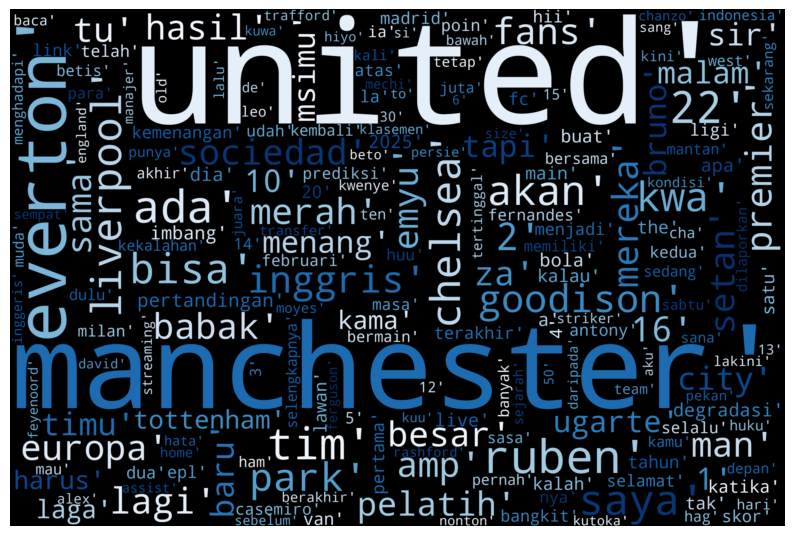

In [24]:
from wordcloud import WordCloud, STOPWORDS

def plot_cloud(wordcloud):
    plt.figure(figsize=(10,8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

all_words = ' '.join([tweets for tweets in data['full_text']])

Wordcloud = WordCloud(
    width=3000,
    height=2000,
    random_state=3,
    background_color='black',
    colormap='Blues_r',
    collocations=False,
    stopwords=STOPWORDS
).generate(all_words)

plot_cloud(Wordcloud)

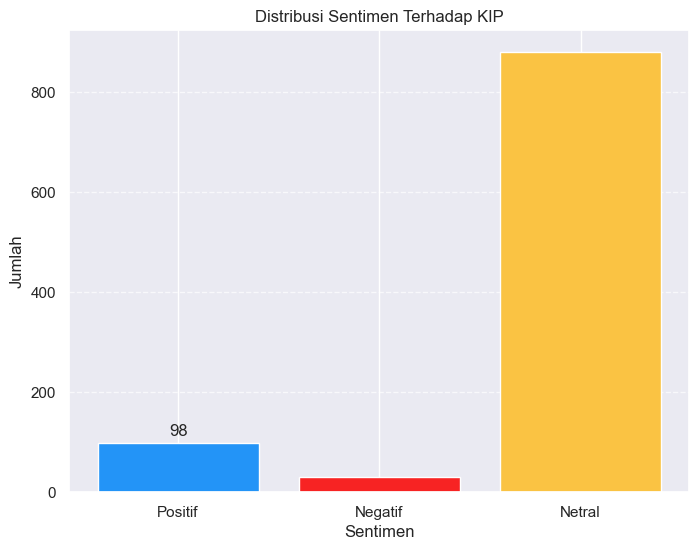

In [25]:
import seaborn as sns

sns.set_theme()

labels = ['Positif','Negatif','Netral']
counts =[total_positif,total_negatif,total_netral]

def show_bar_chart(labels, counts, title):
    fig, ax = plt.subplots(figsize=(8,6))
    bars = ax.bar(labels, counts, color=['#2394f7','#f72323','#fac343'])

    for bar, count in zip(bars,counts):
        height = bar.get_height()
        ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        ax.set_xlabel('Sentimen')
        ax.set_ylabel('Jumlah')
        ax.set_title(title)

        plt.show()

show_bar_chart(labels,counts,"Distribusi Sentimen Terhadap KIP")

# 5. Multinomial Naive Bayes

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

In [27]:
data.head()

,full_text,klasifikasi
0,"['nashukuru', 'sana']",Netral
1,"['efisiensi', 'taik', 'anjing']",Netral
2,['naonewa'],Netral
3,"['arne', 'slot', 'bisa', 'langsung', 'nyetel',...",Netral
4,"['manchester', 'united', 'fans', 'majuu', 'san...",Netral


In [28]:
data.shape

(1009, 2)

In [29]:
data.klasifikasi.unique()

array(['Netral', 'Positif', 'Negatif'], dtype=object)

In [30]:
data.klasifikasi.value_counts()

klasifikasi
Netral     880
Positif     98
Negatif     31
Name: count, dtype: int64

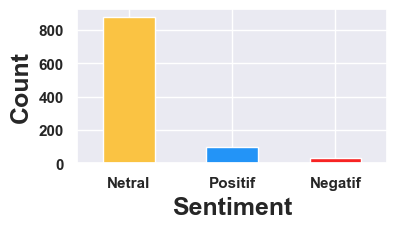

In [31]:
data.klasifikasi.value_counts().plot(kind='bar', figsize=(4, 2), rot=0, color=['#fac343', '#2394f7', '#f72323'])
plt.xlabel('Sentiment', fontweight='bold', fontsize=18)
plt.ylabel('Count', fontweight='bold', fontsize=18)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold');

In [32]:
labelencoder = LabelEncoder()
data['Target'] = labelencoder.fit_transform(data['klasifikasi'])

In [33]:
data.Target.unique()

array([1, 2, 0])

In [34]:
X = data.full_text
y = data.Target

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

In [36]:
len(X_train), len(X_test), len(y_train), len(y_test)

(807, 202, 807, 202)

In [37]:
clf = Pipeline([
    ('cv', CountVectorizer()),
    ('mnb', MultinomialNB(force_alpha=False))
])

In [38]:
clf.fit(X_train, y_train)

Pipeline(steps=[('cv', CountVectorizer()),
                ('mnb', MultinomialNB(force_alpha=False))])

In [39]:
print('Accuracy on the test set:', round(clf.score(X_test, y_test), 4))

Accuracy on the test set: 0.9059


In [40]:
y_pred = clf.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels=clf.classes_)

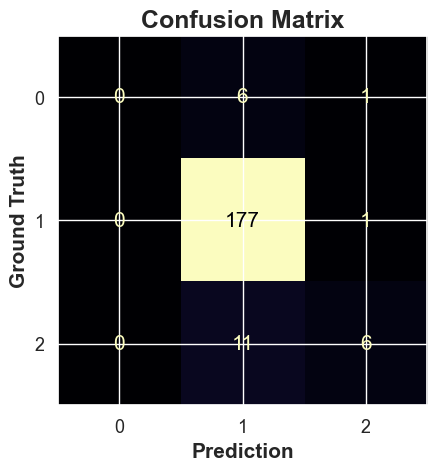

In [41]:

disp.plot(cmap='magma', colorbar=False, text_kw={'size': 15})

plt.xlabel('Prediction', fontsize=15, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=15, fontweight='bold')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')

plt.xticks(fontsize=13)
plt.yticks(fontsize=13);

In [42]:
cat_labels = ['negative', 'neutral', 'positive']
y_pred = clf.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels=cat_labels)

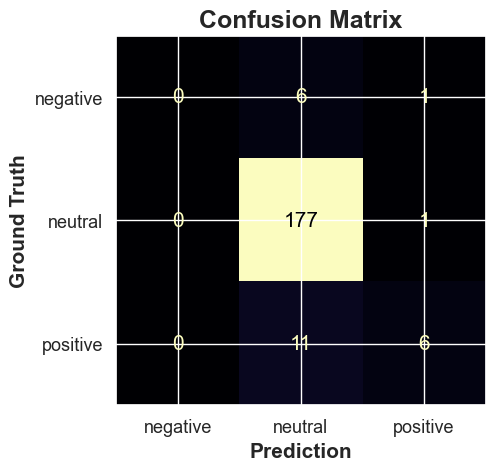

In [43]:
disp.plot(cmap='magma', colorbar=False, text_kw={'size': 15})

plt.xlabel('Prediction', fontsize=15, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=15, fontweight='bold')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')

plt.xticks(fontsize=13)
plt.yticks(fontsize=13);

In [44]:
print('F1 score:', round(metrics.f1_score(y_test, y_pred, average='micro'), 4))

F1 score: 0.9059


In [45]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.91      0.99      0.95       178
           2       0.75      0.35      0.48        17

    accuracy                           0.91       202
   macro avg       0.55      0.45      0.48       202
weighted avg       0.87      0.91      0.88       202



c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

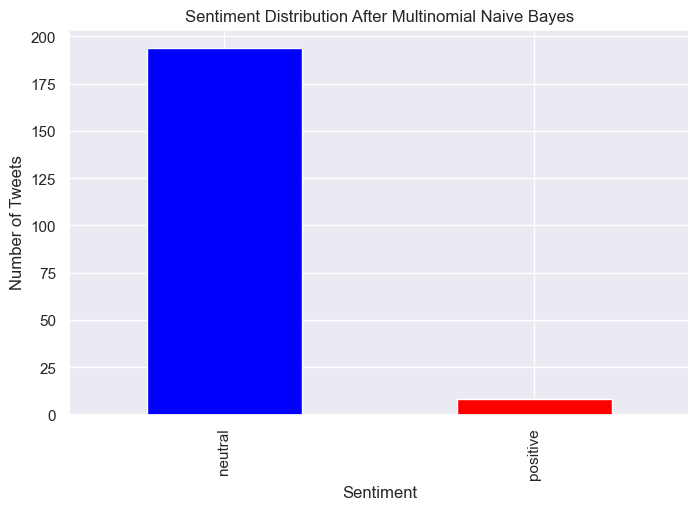

In [46]:
df_result = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

label_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
df_result['Predicted'] = df_result['Predicted'].map(label_mapping)

sentiment_count = df_result['Predicted'].value_counts()

plt.figure(figsize=(8,5))
sentiment_count.plot(kind='bar', color=['blue', 'red', 'yellow'])
plt.title('Sentiment Distribution After Multinomial Naive Bayes')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()